In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("research_data.csv")

In [9]:
df.count

<bound method DataFrame.count of                              Time  Gas  Dust  Temp  Humidity  Label
0      2026-04-05 23:46:16.642632  910     0  26.2      54.4      1
1      2026-04-05 23:46:18.658042  833     0  26.2      54.4      1
2      2026-04-05 23:46:20.675304  693     0  26.2      54.3      0
3      2026-04-05 23:46:22.691498  796     0  26.2      54.3      0
4      2026-04-05 23:46:24.707171  932     0  26.2      54.3      1
...                           ...  ...   ...   ...       ...    ...
20737  2026-04-06 11:23:02.558616  882     0  26.6      51.0      1
20738  2026-04-06 11:23:04.576705  761     0  26.7      50.9      0
20739  2026-04-06 11:23:06.590558  768     0  26.7      50.9      0
20740  2026-04-06 11:23:08.607307  879     0  26.7      50.9      1
20741  2026-04-06 11:23:10.623323  944     6  26.7      50.8      1

[20742 rows x 6 columns]>

In [11]:
df.head()

,Time,Gas,Dust,Temp,Humidity,Label
0,2026-04-05 23:46:16.642632,910,0,26.2,54.4,1
1,2026-04-05 23:46:18.658042,833,0,26.2,54.4,1
2,2026-04-05 23:46:20.675304,693,0,26.2,54.3,0
3,2026-04-05 23:46:22.691498,796,0,26.2,54.3,0
4,2026-04-05 23:46:24.707171,932,0,26.2,54.3,1


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20742 entries, 0 to 20741
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time      20742 non-null  str    
 1   Gas       20742 non-null  int64  
 2   Dust      20742 non-null  int64  
 3   Temp      20741 non-null  float64
 4   Humidity  20741 non-null  float64
 5   Label     20742 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 972.4 KB


In [14]:
df.columns = ['time','gas','dust','temp','humidity','label']

In [16]:
df['time'] = pd.to_datetime(df['time'])

In [18]:
df.describe()

,time,gas,dust,temp,humidity,label
count,20742,20742.000000,20742.000000,20741.000000,20741.000000,20742.000000
mean,2026-04-06 05:34:43.849056,844.866599,1.519863,25.220544,56.730659,0.688603
min,2026-04-05 23:46:16.642632,642.000000,0.000000,24.100000,50.000000,0.000000
25%,2026-04-06 02:40:30.539613,782.000000,0.000000,24.400000,54.800000,0.000000
50%,2026-04-06 05:34:44.434226,847.000000,0.000000,25.100000,57.000000,1.000000
75%,2026-04-06 08:28:56.732557,907.000000,0.000000,26.000000,59.200000,1.000000
max,2026-04-06 11:23:10.623323,1150.000000,272.000000,26.700000,61.200000,1.000000
std,NaN,75.655038,6.732161,0.870435,2.701418,0.463076


In [21]:
df['label'].value_counts()

label
1    14283
0     6459
Name: count, dtype: int64

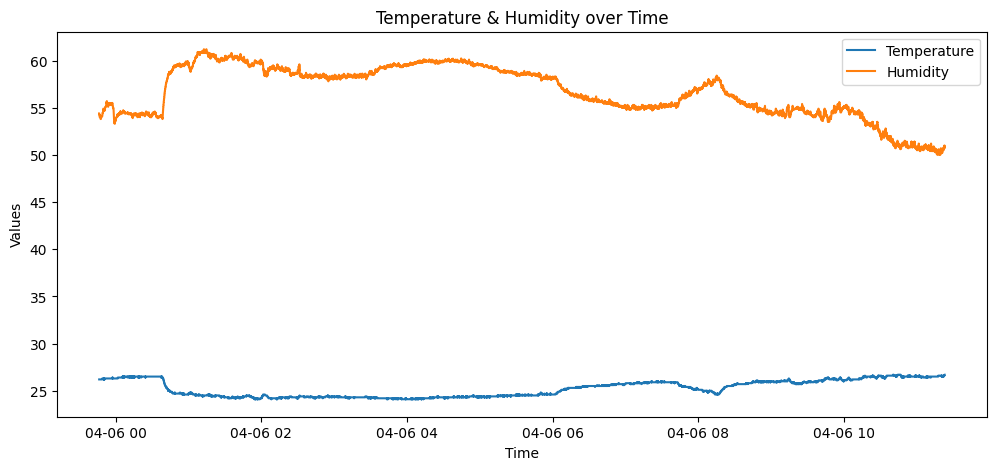

In [23]:
plt.figure(figsize=(12,5))

plt.plot(df['time'], df['temp'], label='Temperature')
plt.plot(df['time'], df['humidity'], label='Humidity')

plt.legend()
plt.title("Temperature & Humidity over Time")
plt.xlabel("Time")
plt.ylabel("Values")

plt.show()

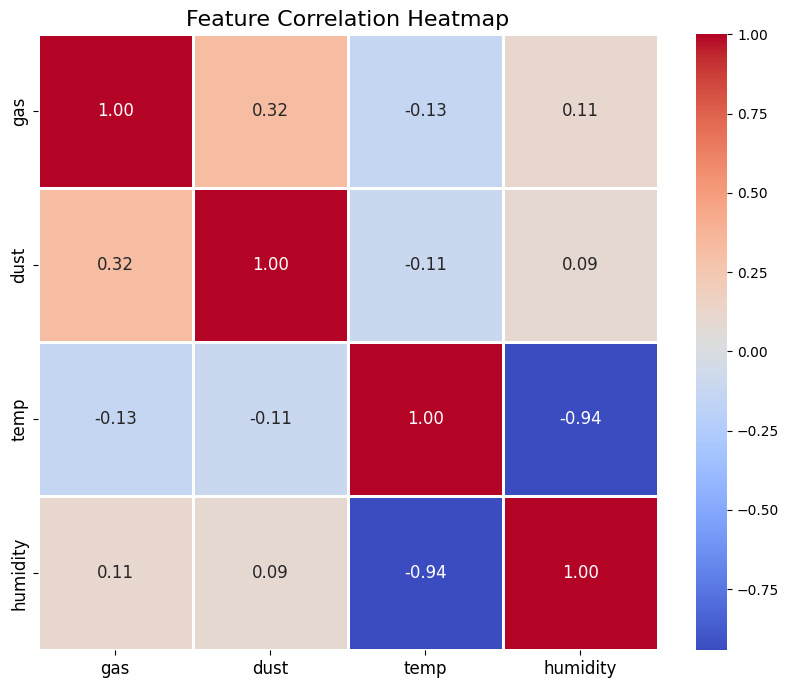

In [26]:
plt.figure(figsize=(10,8))  # increase size

sns.heatmap(
    df[['gas','dust','temp','humidity']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt=".2f",
    annot_kws={"size":12}  # bigger numbers
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

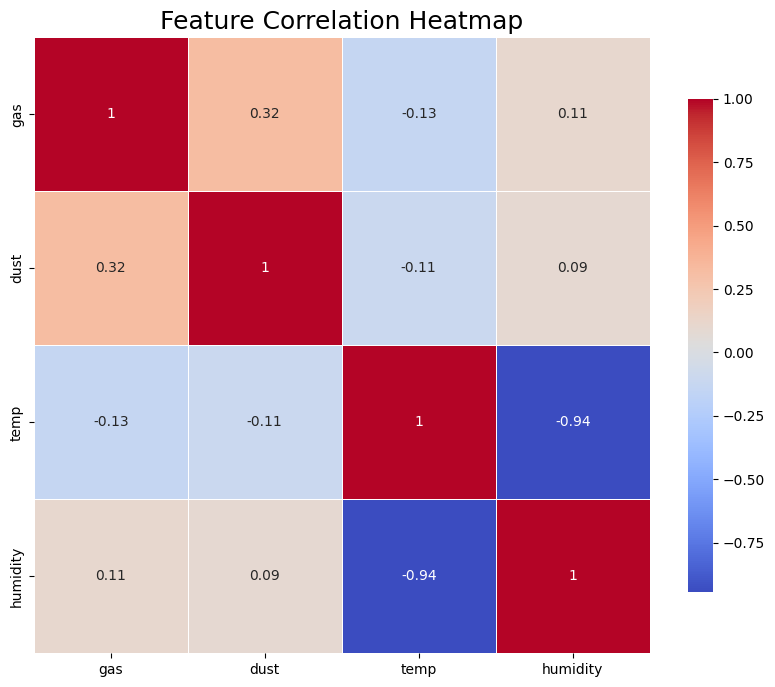

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[['gas','dust','temp','humidity']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Feature Correlation Heatmap", fontsize=18)

plt.show()

In [30]:
df['label'].value_counts()

label
1    14283
0     6459
Name: count, dtype: int64

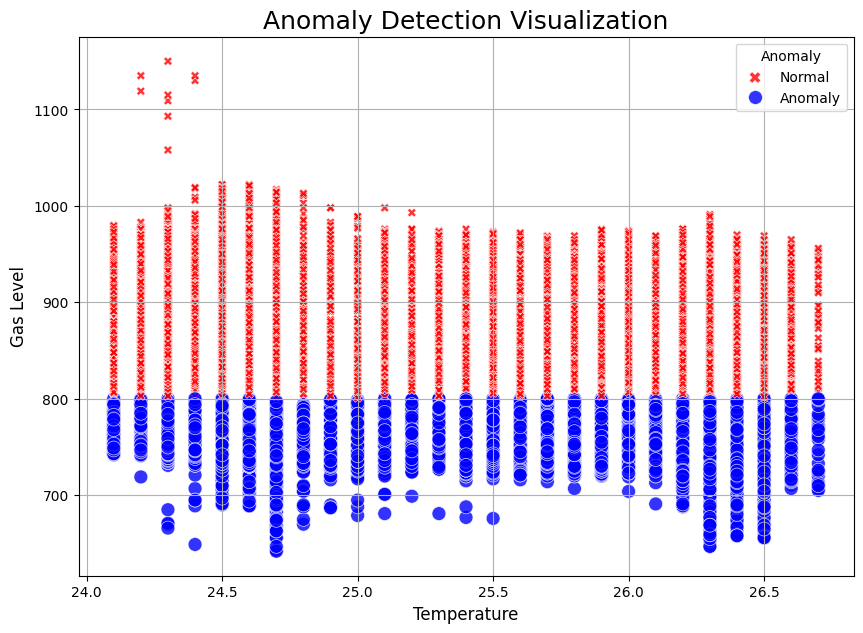

In [34]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='temp',
    y='gas',
    hue='label',
    palette={0: 'blue', 1: 'red'},
    style='label',
    size='label',
    sizes=(40,100),
    alpha=0.8
)

plt.title("Anomaly Detection Visualization", fontsize=18)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Gas Level", fontsize=12)

plt.legend(title="Anomaly", labels=["Normal","Anomaly"])

plt.grid(True)

plt.show()

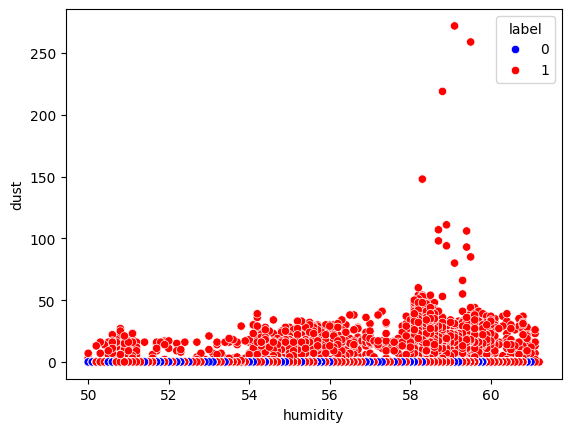

In [36]:
sns.scatterplot(
    data=df,
    x='humidity',
    y='dust',
    hue='label',
    palette={0: 'blue', 1: 'red'}
)
plt.show()

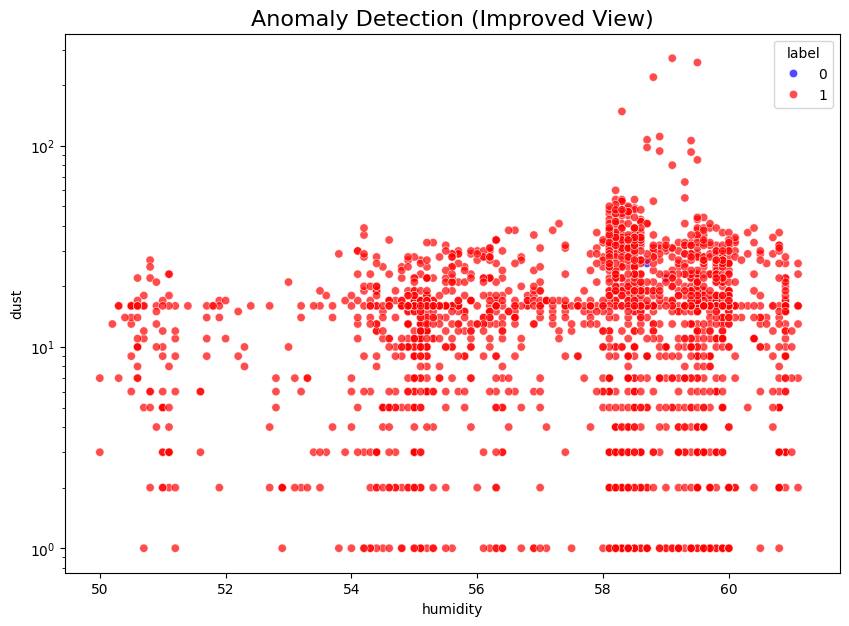

In [38]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='humidity',
    y='dust',
    hue='label',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7
)

plt.yscale('log')  # 🔥 KEY FIX

plt.title("Anomaly Detection (Improved View)", fontsize=16)
plt.show()

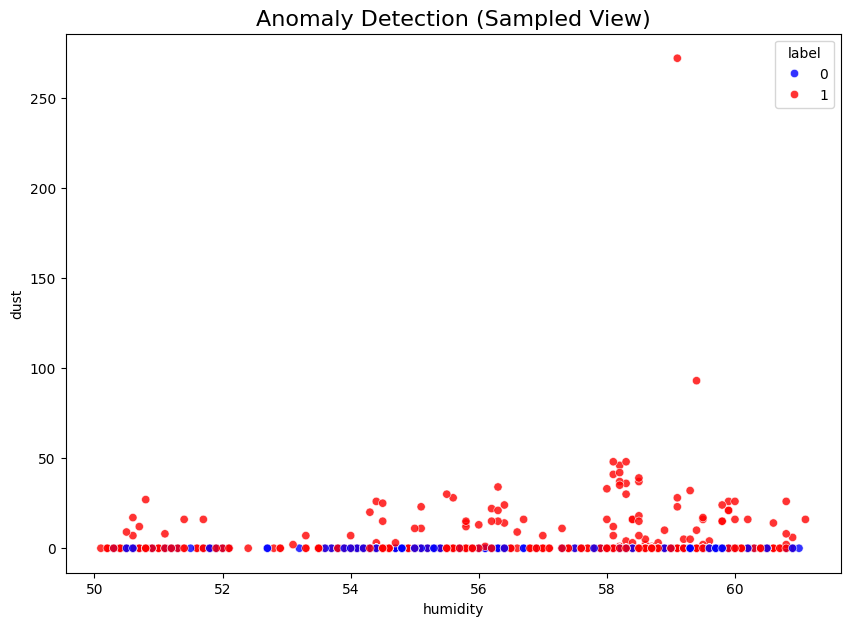

In [39]:
df_sample = df.sample(1000)  # take 1000 points

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_sample,
    x='humidity',
    y='dust',
    hue='label',
    palette={0: 'blue', 1: 'red'},
    alpha=0.8
)

plt.title("Anomaly Detection (Sampled View)", fontsize=16)
plt.show()